# Results: today vs. 2050

Bar charts of burdens, benefits and net impact per impact category for every RAW case, its scaled-up variant and its baselines, with today's and the 2050 background, plus a sweep over product size.

Everything the charts depend on comes from the Google Sheet snapshot: parameters (`case_*`, `baselines`), product formulas and spec values (`products`, `study_setup`), scenarios (`scenarios`), charted categories (`impact_categories`), reference service life (`study_setup`).
Results are per product spec, over the reference service life (each product's burdens and benefits are scaled by reference life / product life).

- **Solid bar (right)**: burdens (materials, production, repair, end-of-life treatment). **Light bar (left)**: benefits (carbon storage, circularity credits). **Dot**: net impact.
- Both backgrounds of a category share one scale: 100 % = the largest burden or benefit of any case in either row.
- Bars have the same thickness in every chart; taller charts compare more cases.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))          # repo root, so that `raw_lca` can be imported
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from raw_lca import Background, Model, load_inputs, run_products, spec_variable
from raw_lca.paths import BACKGROUND, RESULTS, newest_snapshot
from raw_lca.plots import plot_today_vs_2050

SNAPSHOT = newest_snapshot()
inp = load_inputs(SNAPSHOT)                          # validates the sheet snapshot, stops on errors
print("sheet snapshot:", SNAPSHOT.name)

# the two backgrounds shown in the charts: the scenarios flagged in_results on the sheet (first = today)
scn = inp.scenarios[inp.scenarios["in_results"].astype(str).str.upper() == "TRUE"]
(id_a, label_a), (id_b, label_b) = list(zip(scn["scenario_id"], scn["label"]))[:2]
models = {id_a: Model(inp, Background(BACKGROUND, id_a)), id_b: Model(inp, Background(BACKGROUND, id_b))}
(RESULTS / "figures").mkdir(parents=True, exist_ok=True); (RESULTS / "tables").mkdir(parents=True, exist_ok=True)


NOTICE: no sheet snapshot with the redesigned tabs yet - using /Users/tsuitpy/Library/CloudStorage/OneDrive-UniversiteitLeiden/01_Projects/RAW/biobased_construction_impact_calculator/data/sheet_templates


sheet snapshot: sheet_templates


### Status of the input parameters

In [2]:
status = pd.concat([inp.tables[t].assign(tab=t) for t in inp.tables if t.startswith("case_") or t == "baselines"])
display(status.groupby(["case", "status"]).size().unstack(fill_value=0))

status,placeholder
case,
"""traditional"" coreless filament winded beam",3
adobe brick for interior wall,7
clay brick for interior wall,9
glulam beam,7
raw_biopol,61
raw_cfw,44
raw_knit,55
raw_timber,43
reinforced concrete beam,14


## Today vs. 2050, one chart per RAW case

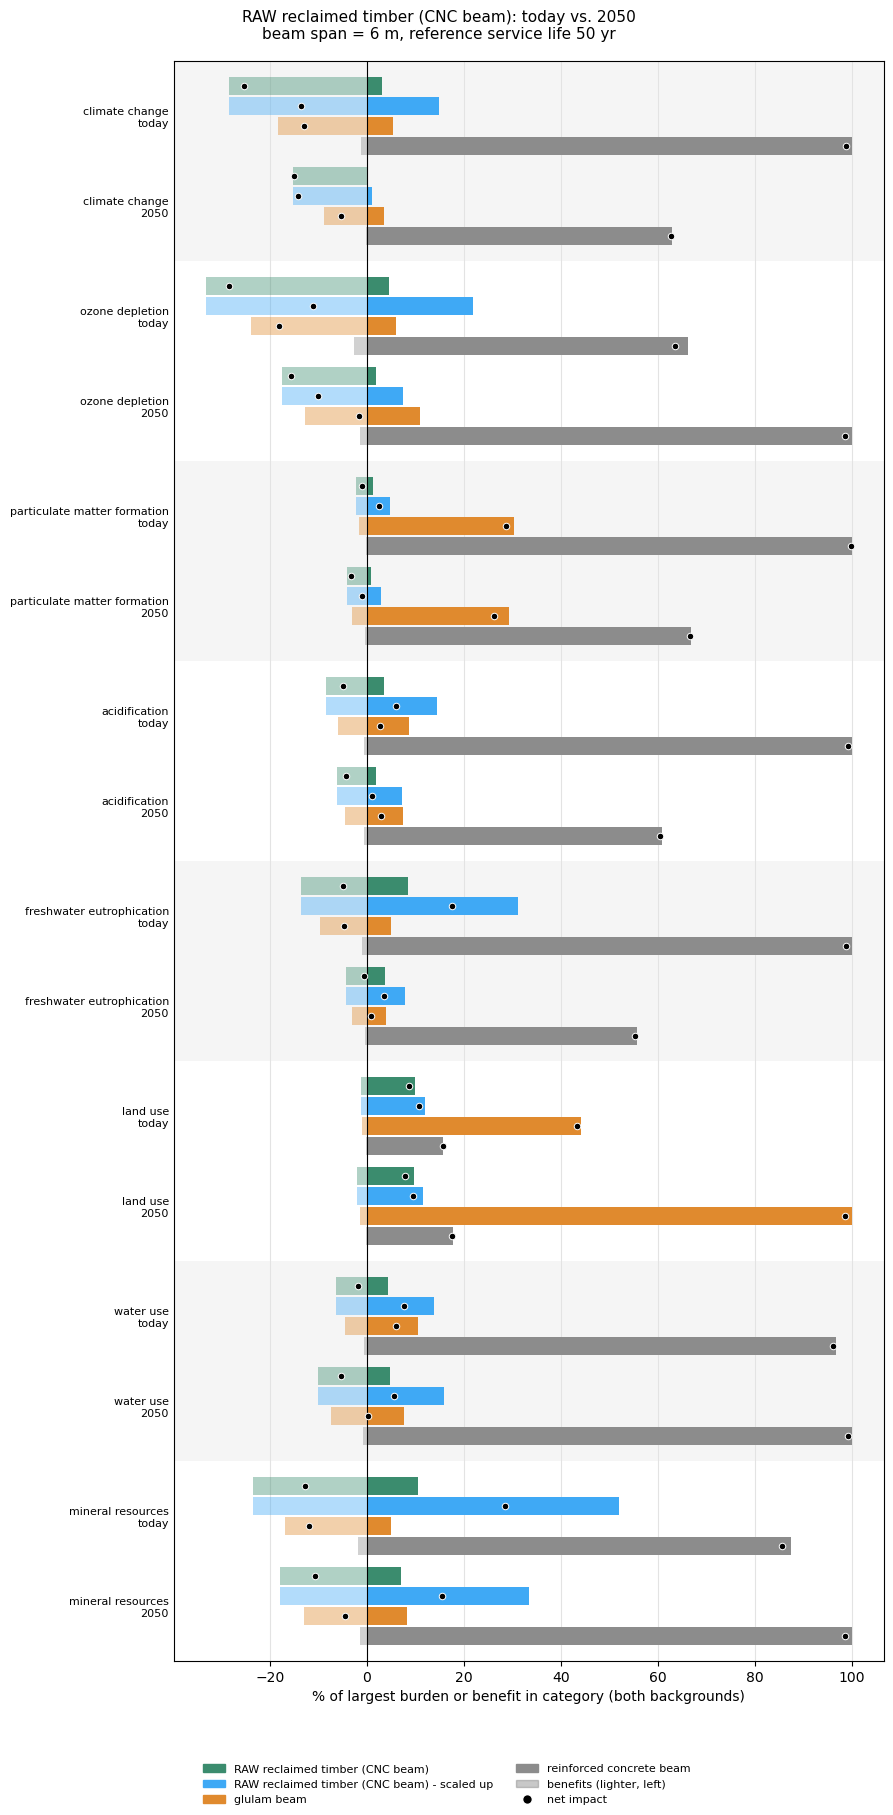

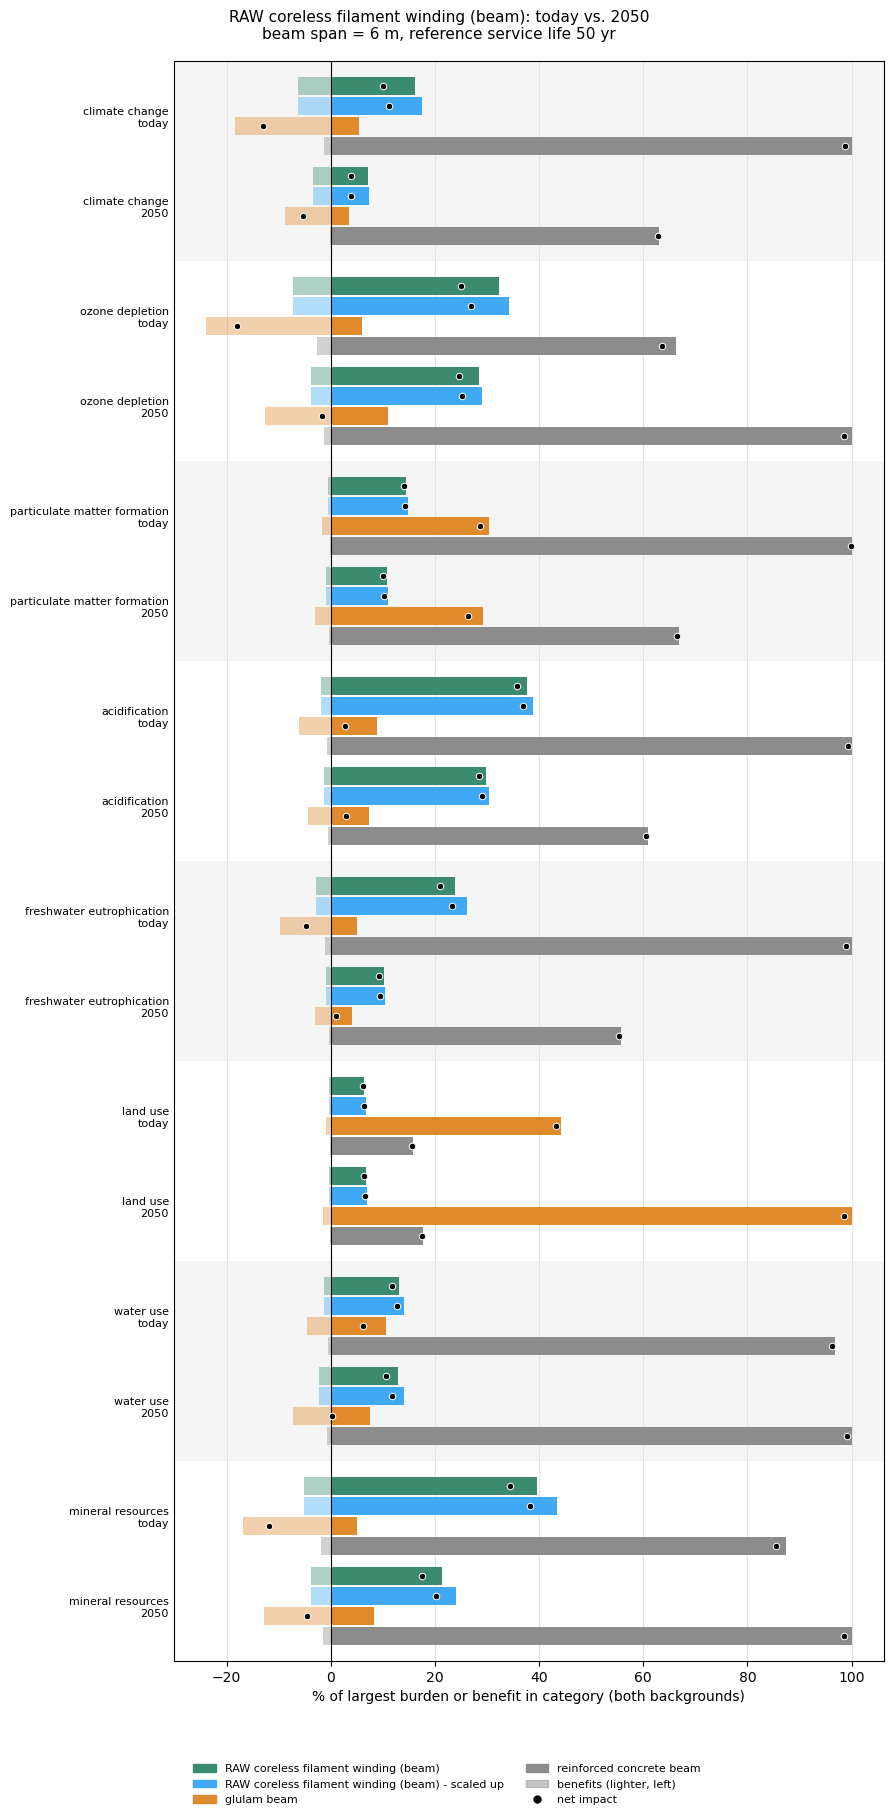

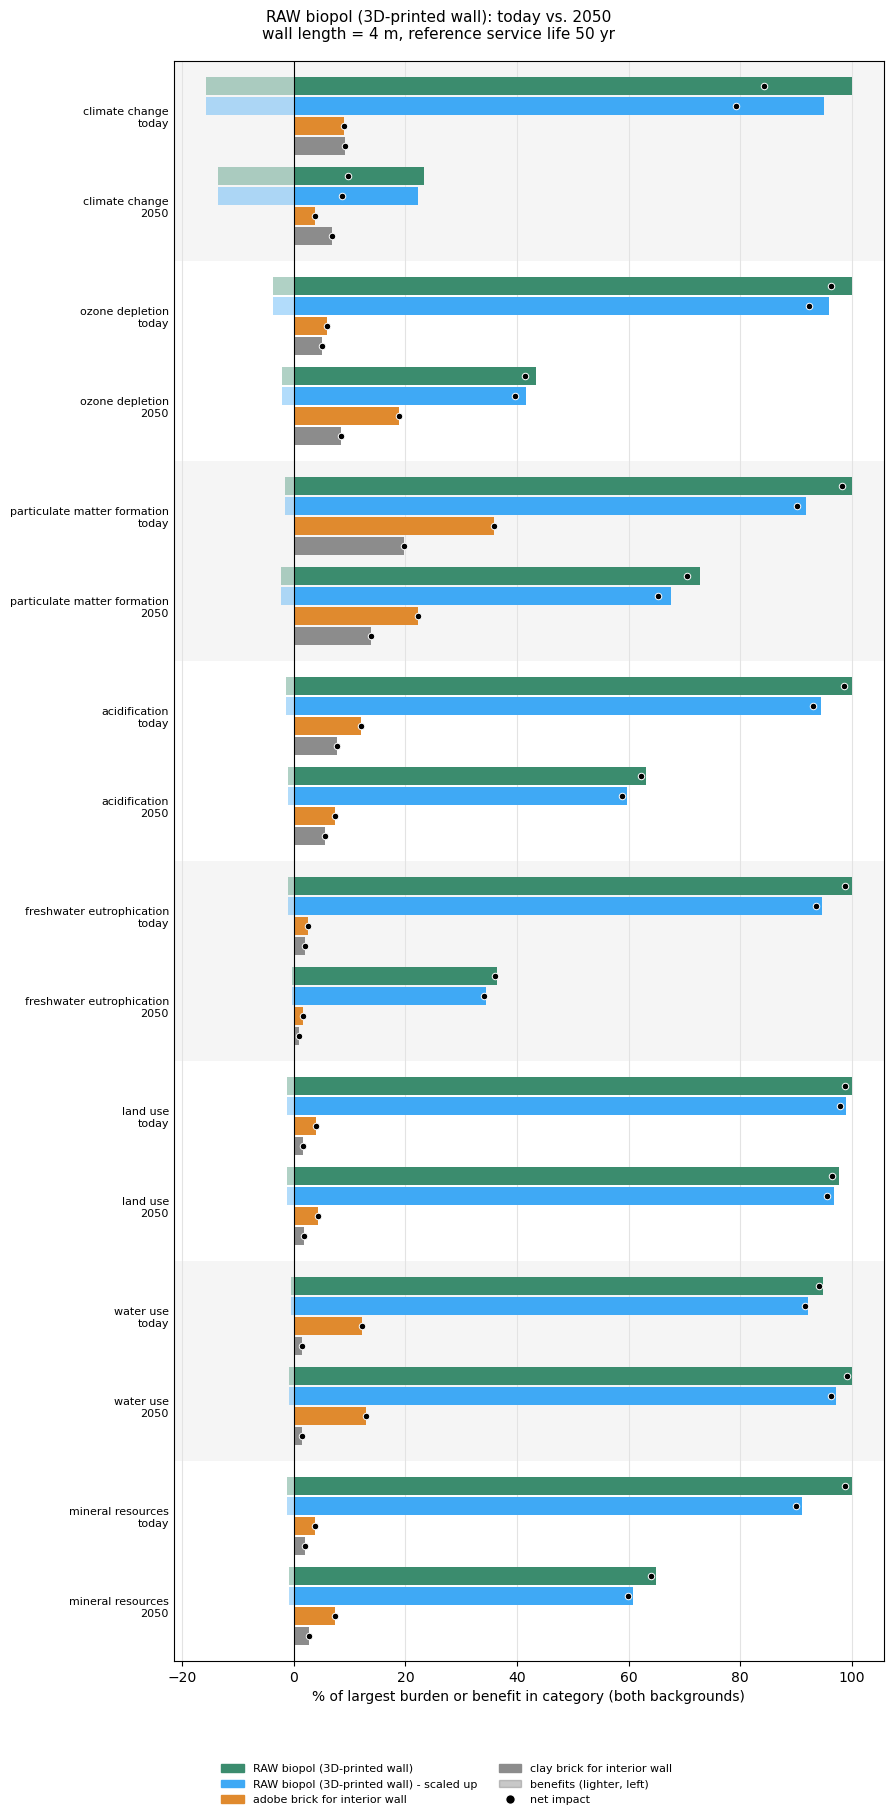

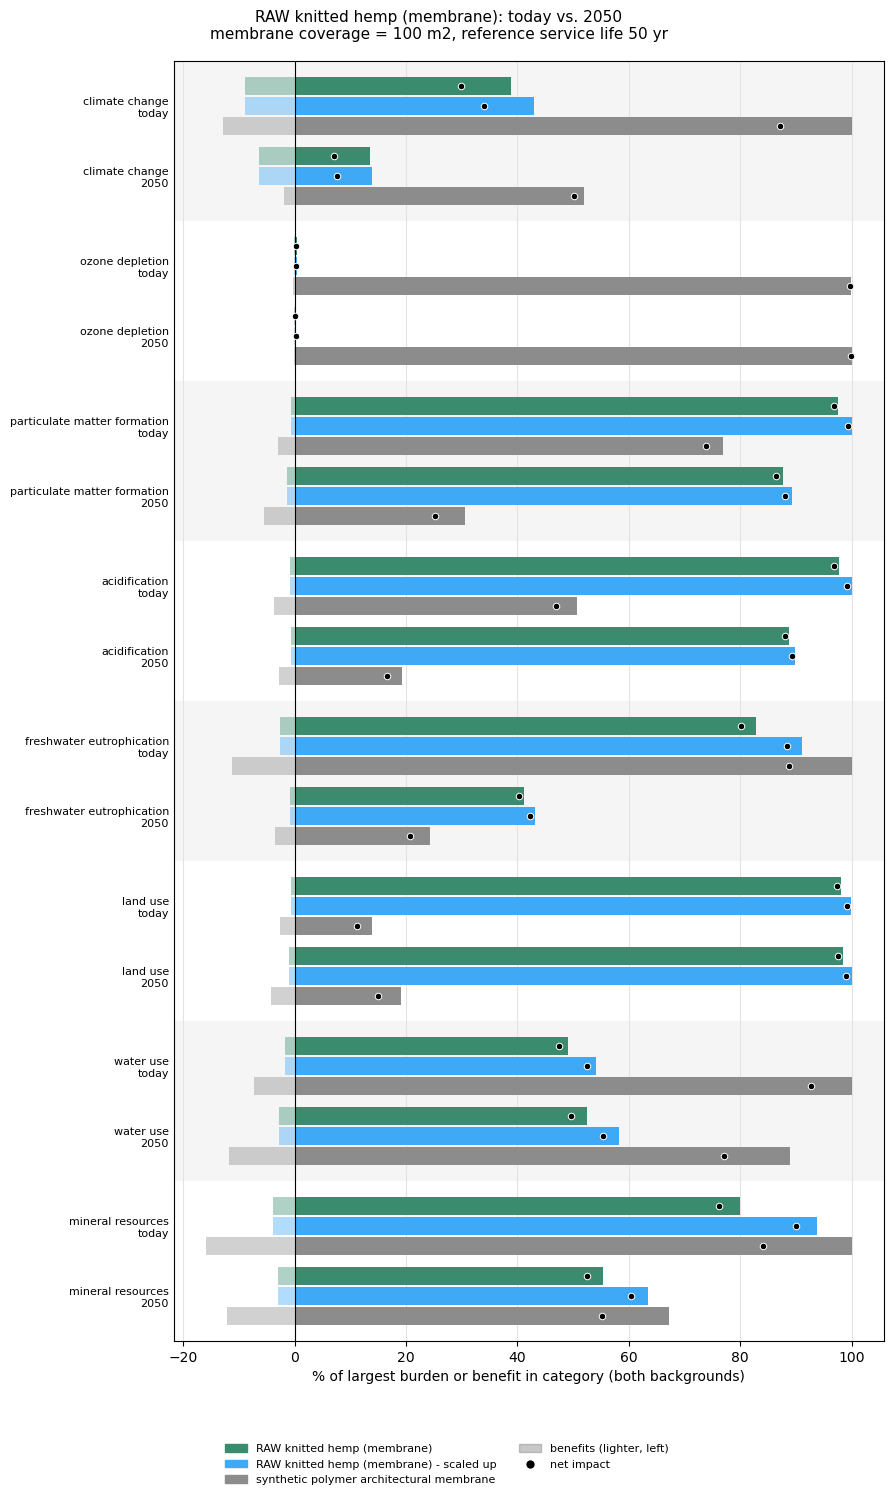

,raw_case,background,product,category,burdens,benefits,net
0,raw_timber,today,RAW reclaimed timber (CNC beam),climate change,11.10,-101.29,-90.19
1,raw_timber,today,RAW reclaimed timber (CNC beam) - scaled up,climate change,52.81,-101.29,-48.49
2,raw_timber,today,glulam beam,climate change,19.18,-65.51,-46.33
3,raw_timber,today,reinforced concrete beam,climate change,356.21,-4.38,351.83
4,raw_timber,2050,RAW reclaimed timber (CNC beam),climate change,0.61,-54.04,-53.43
5,raw_timber,2050,RAW reclaimed timber (CNC beam) - scaled up,climate change,3.73,-54.04,-50.31
6,raw_timber,2050,glulam beam,climate change,12.28,-31.40,-19.12
7,raw_timber,2050,reinforced concrete beam,climate change,224.27,-0.64,223.62
8,raw_cfw,today,RAW coreless filament winding (beam),climate change,57.78,-22.18,35.60
9,raw_cfw,today,RAW coreless filament winding (beam) - scaled up,climate change,62.25,-22.18,40.07


In [3]:
specs = {c: inp.specs[spec_variable(inp, c)] for c in inp.raw_cases()}
summary = []
for case_id, display_name in inp.raw_cases().items():
    row = inp.products[inp.products.case_name == case_id].iloc[0]
    res = {id_a: run_products(models[id_a], case_id), id_b: run_products(models[id_b], case_id)}
    fig = plot_today_vs_2050(inp, f"{display_name}: {label_a} vs. {label_b}\n{row.spec_label} = {specs[case_id]:g} {row.spec_unit}, "
                                  f"reference service life {inp.reference_service_life:g} yr",
                             res[id_a], label_a, res[id_b], label_b)
    fig.savefig(RESULTS / "figures" / f"bars_{case_id}.png", dpi=150); fig.savefig(RESULTS / "figures" / f"bars_{case_id}.pdf")
    plt.show()
    for sid, lab in ((id_a, label_a), (id_b, label_b)):
        for label, r in res[sid].items():
            summary.append(dict(raw_case=case_id, background=lab, product=label, category="climate change",
                                burdens=r.burdens[models[sid].gwp], benefits=r.benefits[models[sid].gwp], net=r.net[models[sid].gwp]))
pd.DataFrame(summary).to_csv(RESULTS / "tables" / "net_gwp_typical_values.csv", index=False)
display(pd.DataFrame(summary).round(2))

## Sweep over product size

The product formulas are non-linear in the spec (e.g. glulam volume grows with span^3), so which product wins can depend on the size. The range of each spec is set on the sheet (`study_setup`: `sweep_*`). Net climate change, today's background.

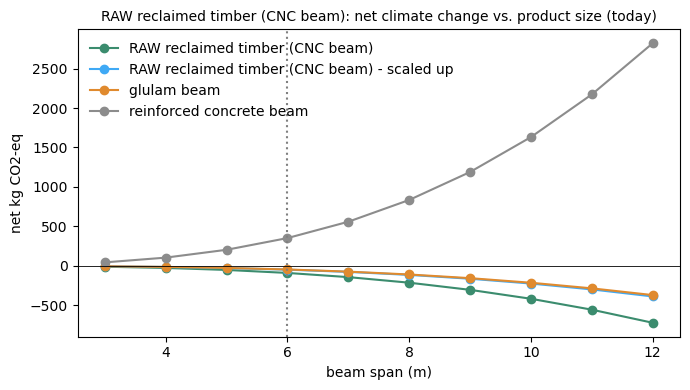

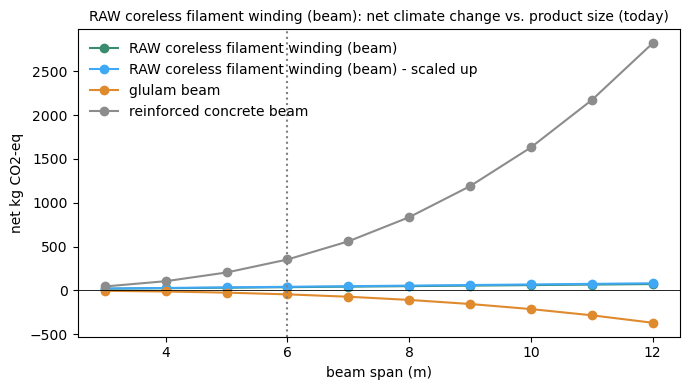

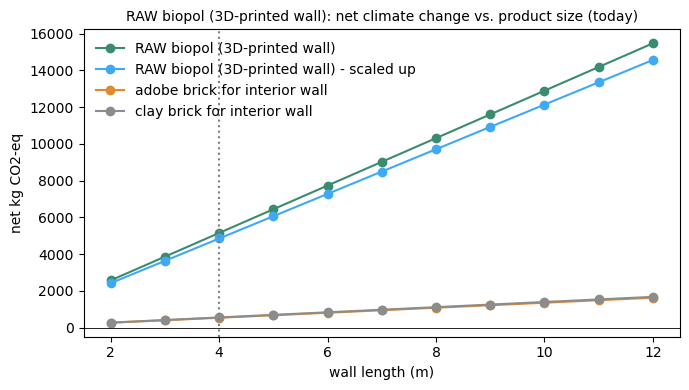

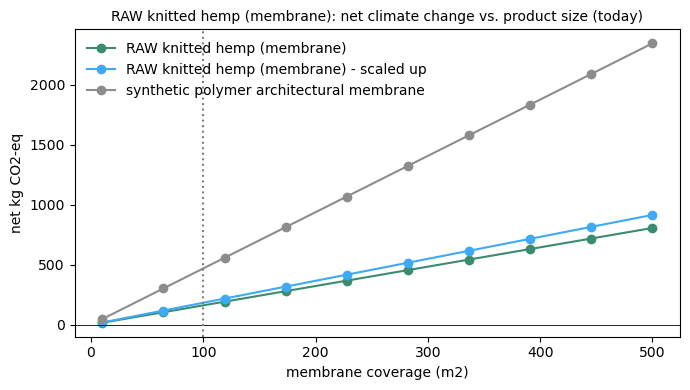

In [4]:
from raw_lca.plots import plot_sweep
for case_id, display_name in inp.raw_cases().items():
    var = spec_variable(inp, case_id); row = inp.products[inp.products.case_name == case_id].iloc[0]
    series = {}
    for x in inp.sweeps[var]:
        for label, r in run_products(models[id_a], case_id, spec_value=float(x)).items():
            series.setdefault(label, []).append(r.net[models[id_a].gwp])
    fig = plot_sweep(inp, row.spec_label, row.spec_unit, inp.sweeps[var], series, specs[case_id],
                     f"{display_name}: net climate change vs. product size ({label_a})")
    fig.savefig(RESULTS / "figures" / f"sweep_{case_id}.png", dpi=150)
    plt.show()